# 2. Generate a known signal
## 2.1 Equation of the sinusoid

A sinusoid with frequency f = 1 Hz, amplitude A = 1 and phase φ = 0 is:

$$s(t) = A \sin(2\pi f t + \varphi) = \sin(2\pi t)$$

For the three axes, a phase shift of π/4 is added from x to y and from y to z:

$$x(t) = \sin(2\pi t), \quad y(t) = \sin\left(2\pi t + \frac{\pi}{4}\right), \quad z(t) = \sin\left(2\pi t + \frac{\pi}{2}\right)$$

## 2.2 Time vector

A column vector t with 100 samples from 0 to 3 s.
Note: the assignment text mentions 1000 samples, but the expected output shows t.shape = (100, 1) over 3 s, so we use 100 samples. This corresponds to a sampling frequency of approximately 33.3 Hz.

In [17]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Time vector: 100 samples over 3 s, as a column vector
t = np.linspace(0, 3, 100).reshape(-1, 1)

print("t.shape =", t.shape)   # expected: (100, 1)

t.shape = (100, 1)


## 2.3 Signal (x, y, z)

A 2D array `s` with one sinusoid per column (x, y, z). The phase shift is π/4 from x to y and from y to z.

In [18]:
# Phase shift between axes
phase_shift = np.pi / 4
phases = np.array([0, 1, 2]) * phase_shift   # [0, pi/4, pi/2]

# Signal: 1 Hz, amplitude 1, one column per axis
s = np.sin(2 * np.pi * 1 * t + phases)

print("s.shape =", s.shape)   # expected: (100, 3)

s.shape = (100, 3)


## 2.4 Output: text, 2D plot and 3D plot

t.shape = (100, 1)
s.shape = (100, 3)
phase_shift = 0.25 pi


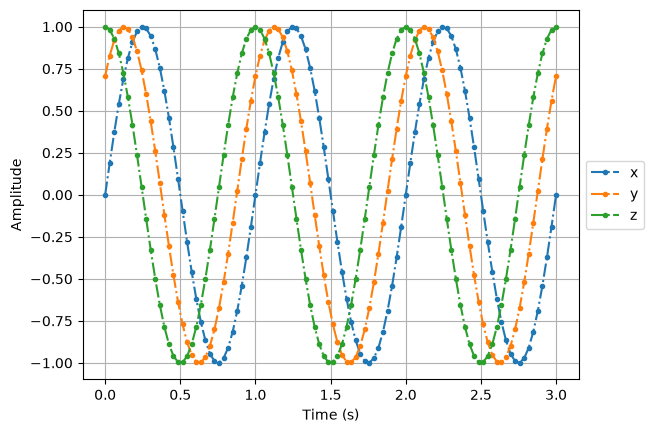

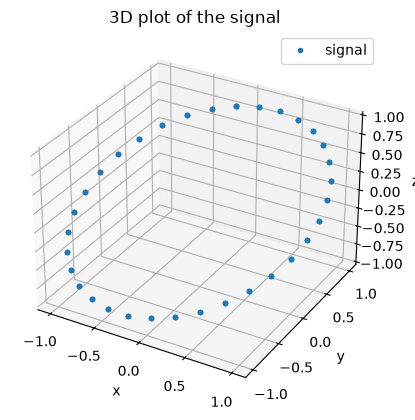

In [19]:
# Text output
print(f"t.shape = {t.shape}")
print(f"s.shape = {s.shape}")
print(f"phase_shift = {phase_shift / np.pi} pi")

# 2D plot: x, y, z over time
fig, ax = plt.subplots()
for i, name in enumerate(["x", "y", "z"]):
    ax.plot(t, s[:, i], ".-.", label=name)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(True)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

# 3D plot: trajectory of the signal
fig = plt.figure()
ax3 = fig.add_subplot(projection="3d")
ax3.plot(s[:, 0], s[:, 1], s[:, 2], ".", label="signal")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")
ax3.set_title("3D plot of the signal")
ax3.legend()
plt.show()

# 3. Estimate the time derivative of the signal

## 3.1 Math: derivative of a sine wave

The derivative of $A\sin(2\pi f t + \varphi)$ with respect to time is:

$$\frac{d}{dt}\left[A \sin(2\pi f t + \varphi)\right] = 2\pi f A \cos(2\pi f t + \varphi)$$

With $A = 1$ and $f = 1$ Hz, the factor $2\pi f A = 2\pi \approx 6.28$. So the derivative oscillates between about $-6.28$ and $+6.28$.

## 3.2 Equation of the time derivative along each axis

$$\dot{x}(t) = 2\pi \cos(2\pi t)$$

$$\dot{y}(t) = 2\pi \cos\left(2\pi t + \frac{\pi}{4}\right)$$

$$\dot{z}(t) = 2\pi \cos\left(2\pi t + \frac{\pi}{2}\right)$$

## 3.3 Forward difference vs central difference
A sampled signal $s_i = s(t_i)$ has no formula, so the derivative is estimated from neighbouring samples.

**Forward difference** (uses the current and the next sample):

$$\dot{s}_i \approx \frac{s_{i+1} - s_i}{t_{i+1} - t_i}$$

**Central difference** (uses the previous and the next sample):

$$\dot{s}_i \approx \frac{s_{i+1} - s_{i-1}}{t_{i+1} - t_{i-1}}$$

Differences:
- The forward difference is centred between $t_i$ and $t_{i+1}$, so the estimate is slightly shifted in time. Its error is proportional to the time step $h$ (first order).
- The central difference is centred exactly on $t_i$. Its error is proportional to $h^2$ (second order), so it is more accurate for the same sampling.
- Forward is undefined at the last sample, central at the first and last samples. In our functions, these edge samples use a one-sided difference instead (see 3.4).

Simple example with $s(t) = t^2$ at $t = 1$ and $h = 0.1$ (true derivative: $2t = 2$):
- Forward: $(1.1^2 - 1^2) / 0.1 = (1.21 - 1) / 0.1 = 2.1$
- Central: $(1.1^2 - 0.9^2) / 0.2 = (1.21 - 0.81) / 0.2 = 2.0$

Reference: https://en.wikipedia.org/wiki/Finite_difference

## 3.4 Functions
**Input order:** `(signal, time)`. The signal is the main data we work on, and time only gives its dates. This is the same order as `numpy.gradient(signal, time)`.

**Output shape:** same as `signal`, i.e. (samples, dimensions). At the first and last samples, where the formula can't be applied, a one-sided difference is used, so there are no missing values.

In [ ]:
# Reference for the finite difference formulas:
# https://en.wikipedia.org/wiki/Finite_difference

def forward_difference(signal, time):
    """Time derivative with the forward difference.
    signal: array (samples, dimensions); time: array (samples, 1).
    Returns an array (samples, dimensions)."""
    signal = np.asarray(signal, dtype=float)
    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)
    time = np.asarray(time, dtype=float).reshape(-1, 1)

    derivative = np.empty_like(signal)
    derivative[:-1] = (signal[1:] - signal[:-1]) / (time[1:] - time[:-1])
    derivative[-1] = derivative[-2]          # last sample: reuse the previous backward difference because no forward sample is available
    return derivative


def central_difference(signal, time):
    """Time derivative with the central difference.
    signal: array (samples, dimensions); time: array (samples, 1).
    Returns an array (samples, dimensions)."""
    signal = np.asarray(signal, dtype=float)
    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)
    time = np.asarray(time, dtype=float).reshape(-1, 1)

    derivative = np.empty_like(signal)
    derivative[1:-1] = (signal[2:] - signal[:-2]) / (time[2:] - time[:-2])
    derivative[0] = (signal[1] - signal[0]) / (time[1] - time[0])        # first: forward
    derivative[-1] = (signal[-1] - signal[-2]) / (time[-1] - time[-2])   # last: backward
    return derivative

## 3.5 Apply the functions and plot the results

ds_forward.shape = (100, 3)
ds_central.shape = (100, 3)


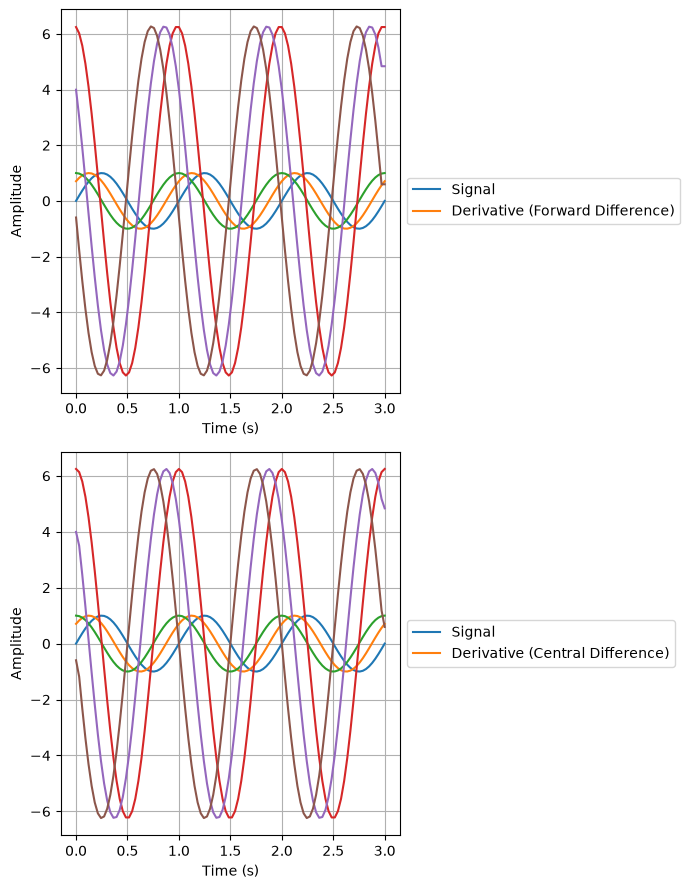

In [15]:
from matplotlib.lines import Line2D

ds_forward = forward_difference(s, t)
ds_central = central_difference(s, t)

print("ds_forward.shape =", ds_forward.shape)
print("ds_central.shape =", ds_central.shape)

fig, axes = plt.subplots(2, 1, figsize=(7, 9))
for ax, ds, method in zip(axes,
                          [ds_forward, ds_central],
                          ["Forward Difference", "Central Difference"]):
    ax.plot(t, s)     # signal: x, y, z
    ax.plot(t, ds)    # derivative: x, y, z
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True)

    # Legend with fixed colours: blue = signal, orange = derivative
    handles = [Line2D([0], [0], color="C0", label="Signal"),
               Line2D([0], [0], color="C1", label=f"Derivative ({method})")]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

### Extra check: comparison with the analytical derivative

The exact derivative is $2\pi\cos(2\pi t + \varphi)$. The maximum error shows which method is more accurate.

In [16]:
ds_exact = 2 * np.pi * np.cos(2 * np.pi * t + phases)

print("Max error, forward:", np.max(np.abs(ds_forward[1:-1] - ds_exact[1:-1])))
print("Max error, central:", np.max(np.abs(ds_central[1:-1] - ds_exact[1:-1])))

Max error, forward: 0.5974806053596778
Max error, central: 0.0378942432860665


**Conclusion of the check**

The maximum error on the inner samples is about **0.60 for the forward difference** and about **0.04 for the central difference**. The central difference is therefore about 16 times more accurate on this signal.

This agrees with the theory: with a time step $h$ (here $h \approx 0.03$ s), the forward difference has an error proportional to $h$, while the central difference has an error proportional to $h^2$. Since $h$ is small, $h^2$ is much smaller than $h$ (for example, $0.03^2 = 0.0009$ versus $0.03$). The forward difference is also shifted by half a sample in time, because it is centred between $t_i$ and $t_{i+1}$, whereas the central difference is centred exactly on $t_i$.

We will therefore prefer the central difference for the rest of the work, and keep the forward difference only when no future sample is available.